<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


<a id="ref0"></a>

# Convolutional Neural Network MNIST


Estimated Time Needed: <strong>25</strong> minutes; <strong>14</strong> minutes to train model


## Learning Objectives
After completing this lab, you will be able to:
- Use a Convolutional Neural Network to classify handwritten digits from the MNIST database
- Reshape the images for faster processing



## Table of Contents

In this lab, you will use a convolutional neural network to classify handwritten digits from the MNIST database. You will reshape the images to make them faster to process.

- <a href="#Install-Libraries">Install Libraries</a>
- <a href="#Get-the-Data">Get the Data</a>
- <a href="#Build-a-Convolutional-Neural-Network-Class">Build a Convolutional Neural Network Class</a>
- <a href="#Train-the-Model">Define the Convolutional Neural Network Classifier, Criterion function, Optimizer, and Train the Model</a>
- <a href="#Analyze-the-Results">Analyze the Results</a>



<a id="Install-Libraries"></a>

## Install Libraries


In [1]:
%%time
%%capture
%pip install pandas numpy matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu

CPU times: user 232 ms, sys: 61.8 ms, total: 294 ms
Wall time: 52.7 s

In [2]:
# Import the libraries we need to use in this lab

# Using the following line code to install the torchvision library
# !mamba install -y torchvision

#!pip install torchvision==0.9.1 torch==1.8.1 
import torch 
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np

Define the function <code>plot_channels</code> to plot out the kernel parameters of  each channel.


In [18]:
# Define the function for plotting the channels

def plot_channels(W):
    """Plot all kernel channels with a readable grid layout.

    Each row represents one output kernel and each column represents one
    input channel for that kernel.
    """
    n_out = W.shape[0]
    n_in = W.shape[1]
    w_min = W.min().item()
    w_max = W.max().item()

    fig_width = max(6, n_in * 2)
    fig_height = max(4, n_out * 1.2)
    fig, axes = plt.subplots(n_out, n_in, figsize=(fig_width, fig_height))
    axes = np.array(axes)
    if n_out == 1 and n_in == 1:
        axes = axes.reshape(1, 1)
    elif n_in == 1:
        axes = axes.reshape(n_out, 1)
    elif n_out == 1:
        axes = axes.reshape(1, n_in)

    for out_index in range(n_out):
        for in_index in range(n_in):
            ax = axes[out_index, in_index]
            ax.imshow(W[out_index, in_index, :, :], vmin=w_min, vmax=w_max, cmap='seismic')
            ax.set_xticks([])
            ax.set_yticks([])
            if n_in > 1:
                ax.set_title("channel:{0}".format(in_index + 1), fontsize=8, pad=4)
        axes[out_index, 0].set_ylabel("kernel:{0}".format(out_index + 1), fontsize=8)

    plt.tight_layout()
    plt.show()

Define the function <code>plot_parameters</code> to plot out the kernel parameters of each channel with Multiple outputs.


In [19]:
# Define the function for plotting the parameters

def plot_parameters(W, number_rows=1, name="", i=0):
    """Plot convolutional kernel parameters for one input channel.

    The function creates a separate figure each time it runs. This spacing
    keeps kernel labels readable when many kernels are displayed.
    """
    W = W.data[:, i, :, :]
    n_filters = W.shape[0]
    w_min = W.min().item()
    w_max = W.max().item()

    number_columns = int(np.ceil(n_filters / number_rows))
    fig_width = max(8, number_columns * 1.5)
    fig_height = max(3, number_rows * 1.7)

    fig, axes = plt.subplots(number_rows, number_columns, figsize=(fig_width, fig_height))
    axes = np.array(axes).reshape(-1)

    for kernel_index, ax in enumerate(axes):
        if kernel_index < n_filters:
            # Plot the kernel values. Red shows positive weights,
            # blue shows negative weights, and lighter values are closer to zero.
            ax.imshow(
                W[kernel_index, :],
                vmin=w_min,
                vmax=w_max,
                cmap='seismic'
            )
            ax.set_title("kernel:{0}".format(kernel_index + 1), fontsize=8, pad=4)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle(name, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

Define the function <code>plot_activation</code> to plot out the activations of the convolutional layers. 


In [20]:
# Define the function for plotting the activations

def plot_activations(A, number_rows=1, name="", i=0):
    """Plot activation maps for a single sample.

    The activations are generated dynamically from the model output, so the
    exact values vary with the sample and the model state.
    """
    A = A[0, :, :, :].detach().numpy()
    n_activations = A.shape[0]
    A_min = A.min().item()
    A_max = A.max().item()

    number_columns = int(np.ceil(n_activations / number_rows))
    fig_width = max(8, number_columns * 1.5)
    fig_height = max(3, number_rows * 1.7)

    fig, axes = plt.subplots(number_rows, number_columns, figsize=(fig_width, fig_height))
    axes = np.array(axes).reshape(-1)

    for activation_index, ax in enumerate(axes):
        if activation_index < n_activations:
            ax.imshow(A[activation_index, :], vmin=A_min, vmax=A_max, cmap='seismic')
            ax.set_title("activation:{0}".format(activation_index + 1), fontsize=8, pad=4)
        else:
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle(name, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

Define the function <code>show_data</code> to plot out data samples as images.


In [21]:
def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    plt.title('y = '+ str(data_sample[1]))

<a id="Get-the-Data"></a>

## Get the Data


We create a transform to resize the image and convert it to a tensor.


In [22]:


IMAGE_SIZE = 16


composed = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor()])

Load the training dataset by setting the parameters <code>train </code> to <code>True</code>. We use the transform defined above.


In [23]:

train_dataset = dsets.MNIST(root='./data', train=True, download=True, transform=composed)

Load the testing dataset by setting the parameters train  <code>False</code>.


In [24]:
# Make the validating 

validation_dataset = dsets.MNIST(root='./data', train=False, download=True, transform=composed)

We can see the data type is long.


In [25]:
# Show the data type for each element in dataset

type(train_dataset[0][1])

int

Each element in the rectangular tensor corresponds to a number representing a pixel intensity as demonstrated by the following image.


<img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.2.1imagenet.png" width="550" alt="MNIST data image">


Print out the fourth label.


In [27]:
# The label for the fourth data element

train_dataset[3][1]

1

Plot the fourth sample.


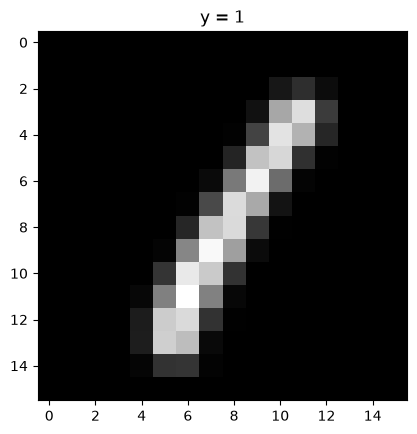

In [26]:
# The image for the fourth data element
show_data(train_dataset[3])


The fourth sample is a "1".


<!--Empty Space for separating topics-->


<a id="Build-a-Convolutional-Neural-Network-Class"></a>

## Build a Convolutional Neural Network Class


Build a Convolutional Network class with two Convolutional layers and one fully connected layer. Pre-determine the size of the final output matrix. The parameters in the constructor are the number of output channels for the first and second layer.


In [28]:
class CNN(nn.Module):
    
    # Contructor
    def __init__(self, out_1=16, out_2=32):
        super(CNN, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.maxpool1=nn.MaxPool2d(kernel_size=2)

        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.maxpool2=nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(out_2 * 4 * 4, 10)
    
    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x
    
    # Outputs in each steps
    def activations(self, x):
        #outputs activation this is not necessary
        z1 = self.cnn1(x)
        a1 = torch.relu(z1)
        out = self.maxpool1(a1)
        
        z2 = self.cnn2(out)
        a2 = torch.relu(z2)
        out1 = self.maxpool2(a2)
        out = out.view(out.size(0),-1)
        return z1, a1, z2, a2, out1,out

<a id="Train-the-Model"></a>

## Define the Convolutional Neural Network Classifier, Criterion function, Optimizer, and Train the Model


There are 16 output channels for the first layer, and 32 output channels for the second layer. 


In [29]:
# Create the model object using CNN class

model = CNN(out_1=16, out_2=32)

Running the following code generates visualizations of the convolutional kernels before training. The kernels are initialized randomly, so your output may vary when you run the notebook.

The first output shows the 16 kernels from the first convolutional layer. The second output shows the 32 kernels from the second convolutional layer. In both outputs, red regions indicate positive weights, blue regions indicate negative weights, and lighter regions are closer to zero.


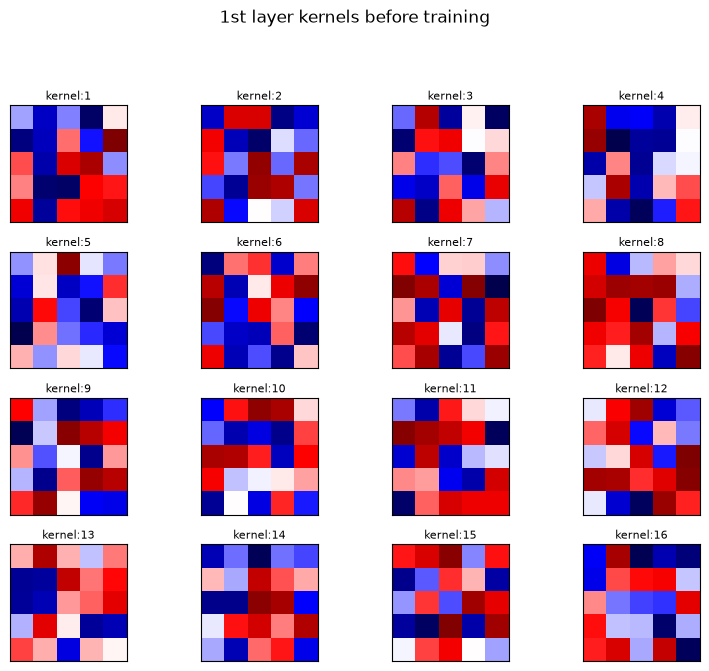

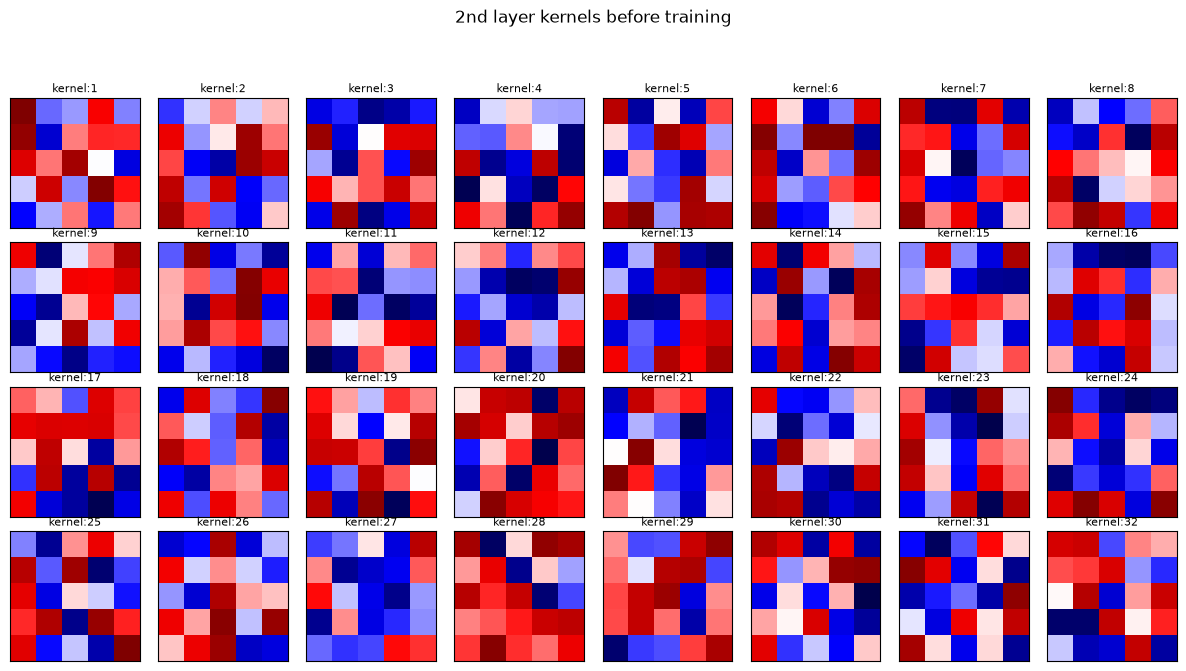

In [30]:
# Plot the first layer kernels before training.

plot_parameters(
    model.state_dict()['cnn1.weight'],
    number_rows=4,
    name="1st layer kernels before training"
)

# Plot the second layer kernels before training.

plot_parameters(
    model.state_dict()['cnn2.weight'],
    number_rows=4,
    name="2nd layer kernels before training"
)

After visualizing the randomly initialized kernels, define the loss function, optimizer, and data loader required to train the model.


In [31]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000)

Train the model and determine validation accuracy technically test accuracy **(This may take a long time)**


In [32]:
# Train the model

n_epochs=3
cost_list=[]
accuracy_list=[]
N_test=len(validation_dataset)
COST=0

def train_model(n_epochs):
    for epoch in range(n_epochs):
        COST=0
        for x, y in train_loader:
            optimizer.zero_grad()
            z = model(x)
            loss = criterion(z, y)
            loss.backward()
            optimizer.step()
            COST+=loss.data
        
        cost_list.append(COST)
        correct=0
        #perform a prediction on the validation  data  
        for x_test, y_test in validation_loader:
            z = model(x_test)
            _, yhat = torch.max(z.data, 1)
            correct += (yhat == y_test).sum().item()
        accuracy = correct / N_test
        accuracy_list.append(accuracy)
     
train_model(n_epochs)

<!--Empty Space for separating topics-->


<a id="Analyze-the-Results"></a>

## Analyze the Results


Plot the loss and accuracy on the validation data:


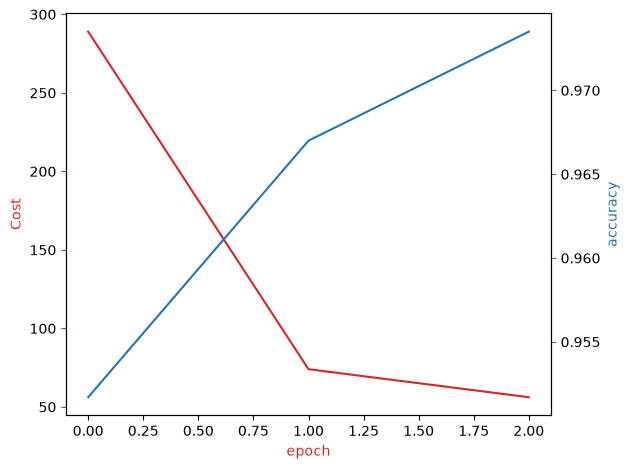

In [33]:
# Plot the loss and accuracy

fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(cost_list, color=color)
ax1.set_xlabel('epoch', color=color)
ax1.set_ylabel('Cost', color=color)
ax1.tick_params(axis='y', color=color)
    
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color) 
ax2.set_xlabel('epoch', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()

View the results of the parameters for the Convolutional layers.


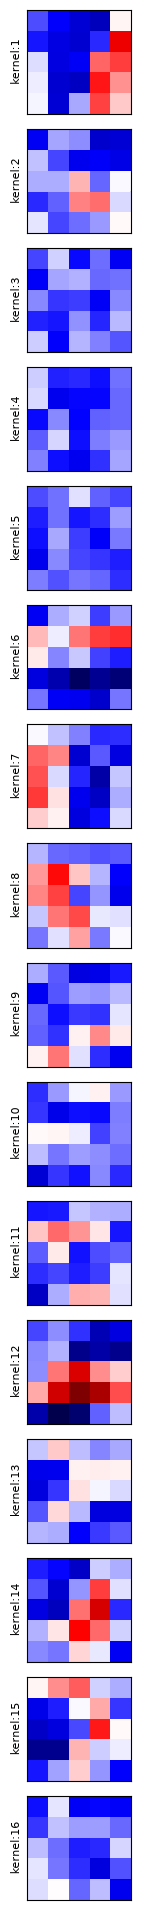

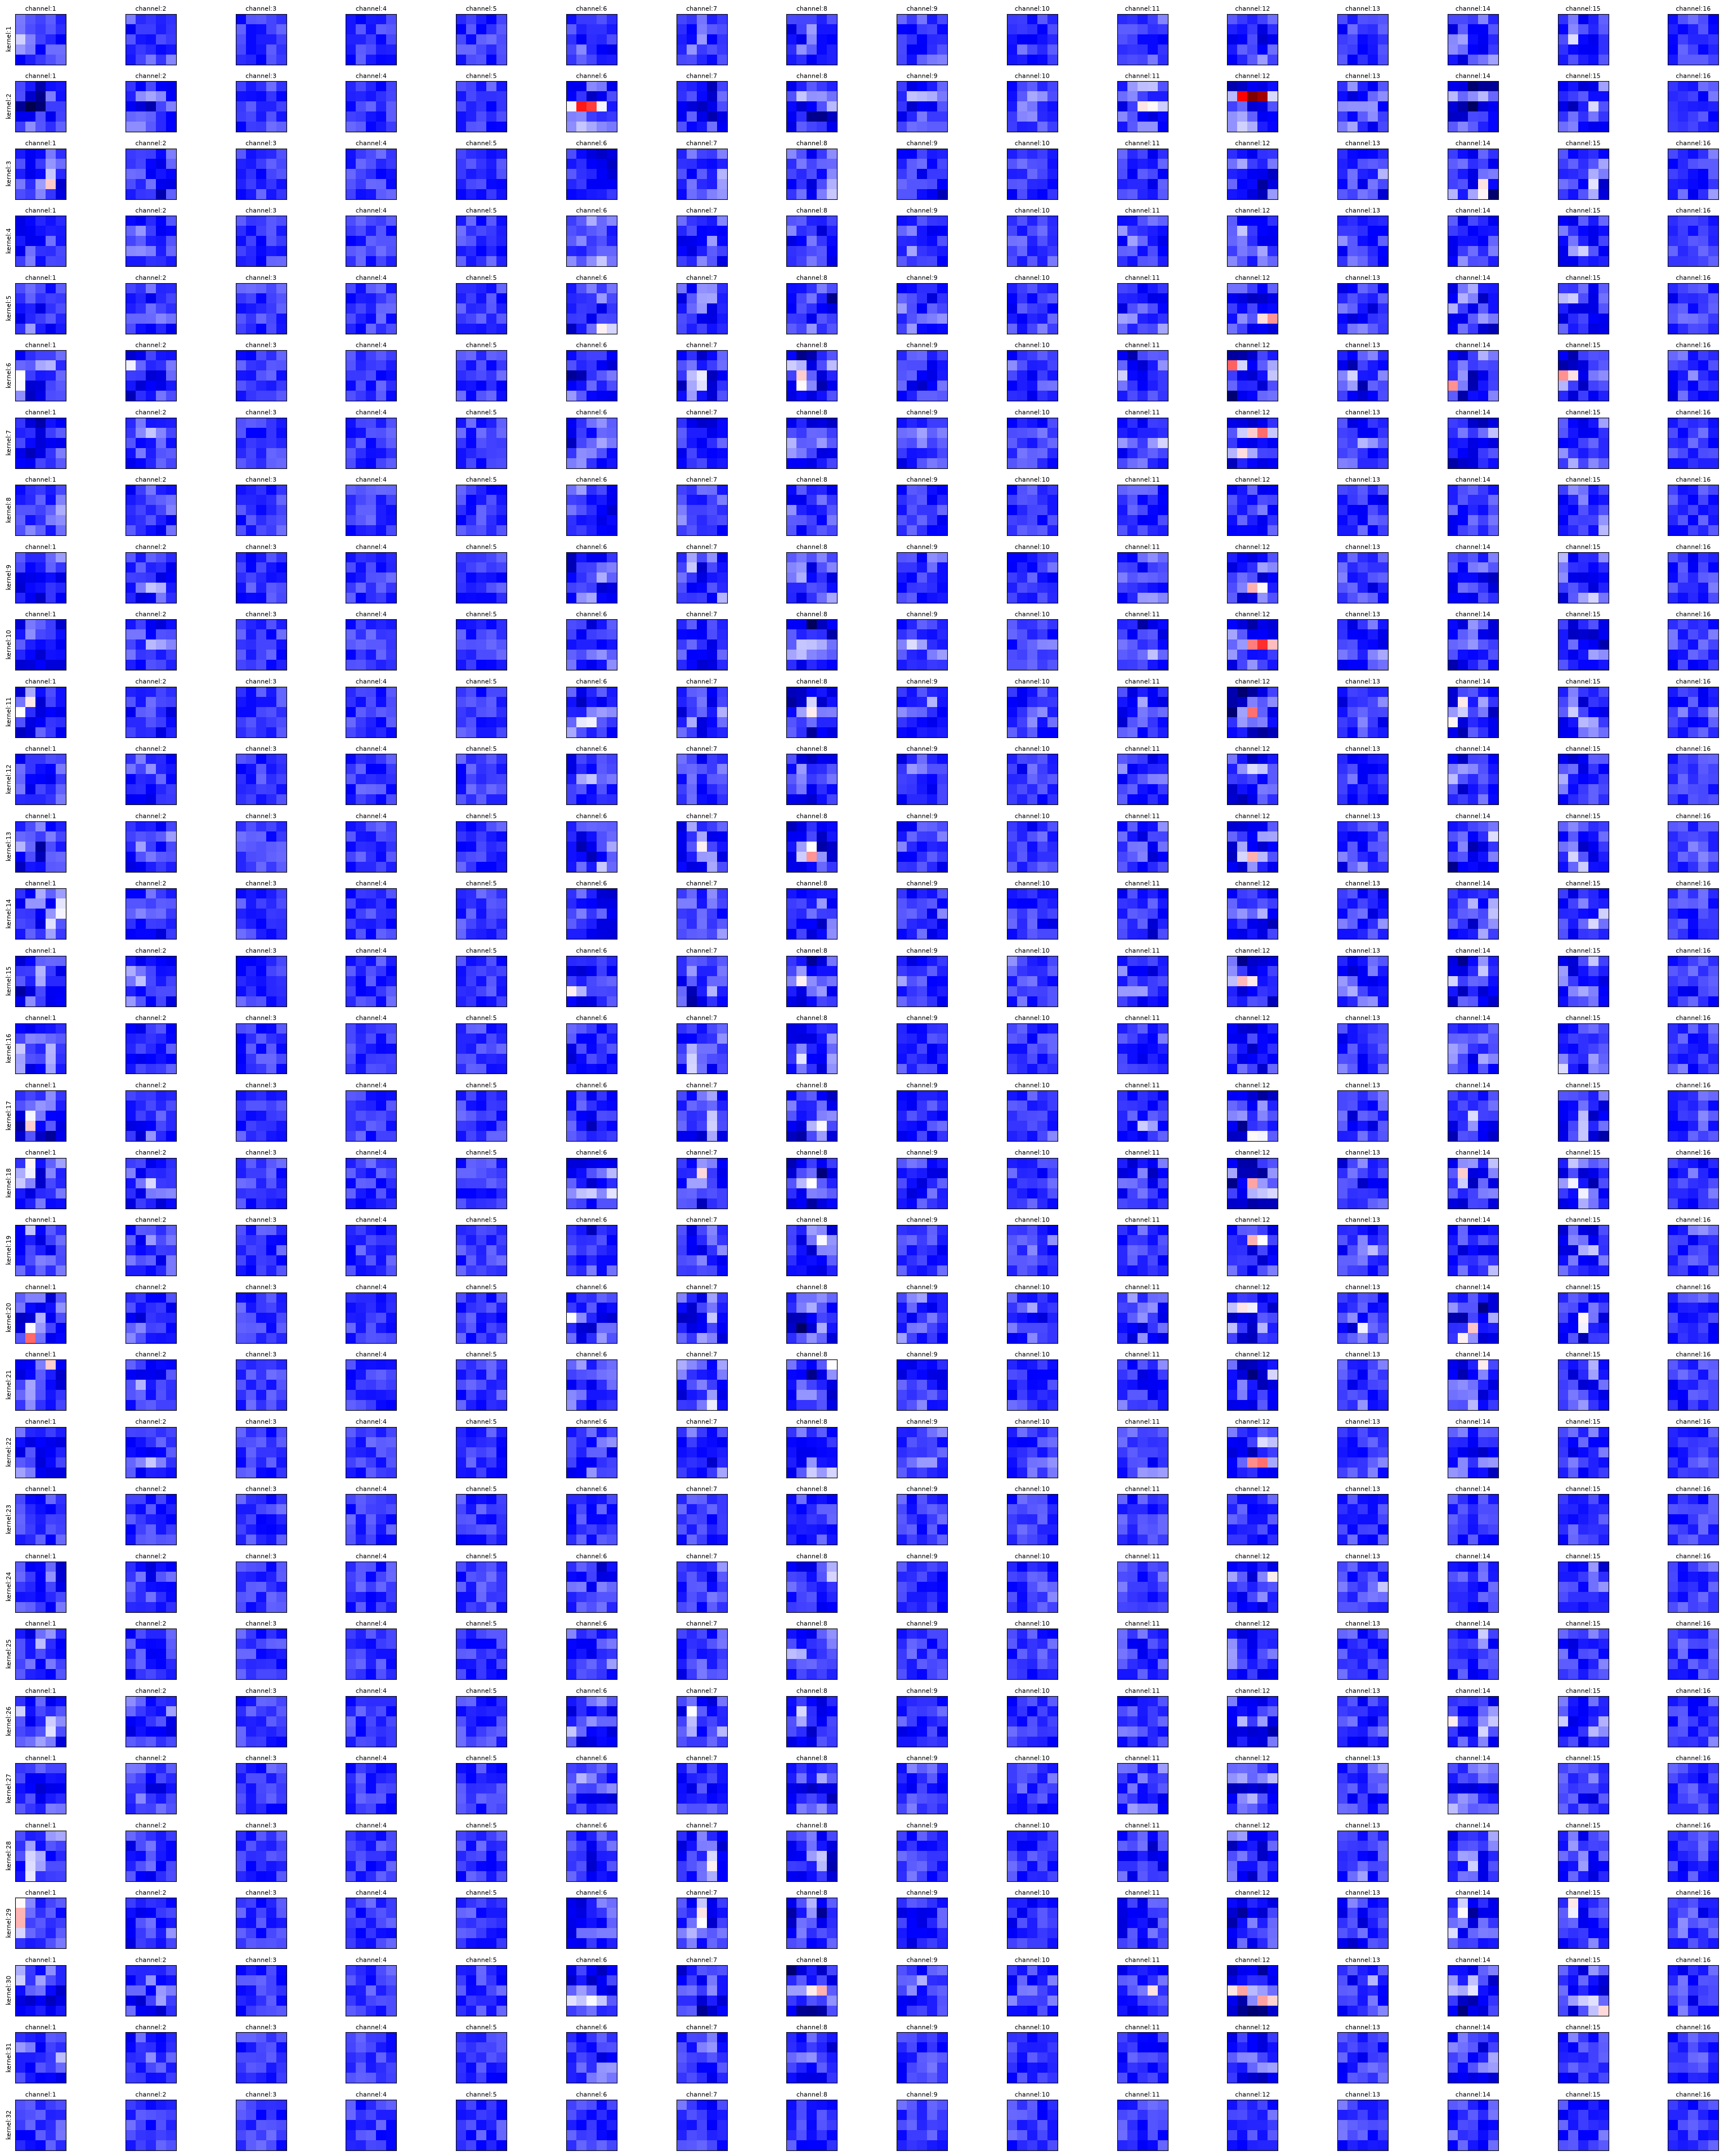

In [34]:
# Plot the channels

plot_channels(model.state_dict()['cnn1.weight'])
plot_channels(model.state_dict()['cnn2.weight'])

Consider the following sample:


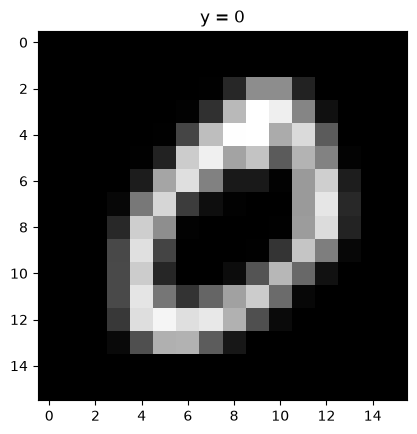

In [35]:
# Show the second image

show_data(train_dataset[1])

Determine the activations.


In [36]:
# Use the CNN activations class to see the steps

out = model.activations(train_dataset[1][0].view(1, 1, IMAGE_SIZE, IMAGE_SIZE))

Plot out the first set of activations.


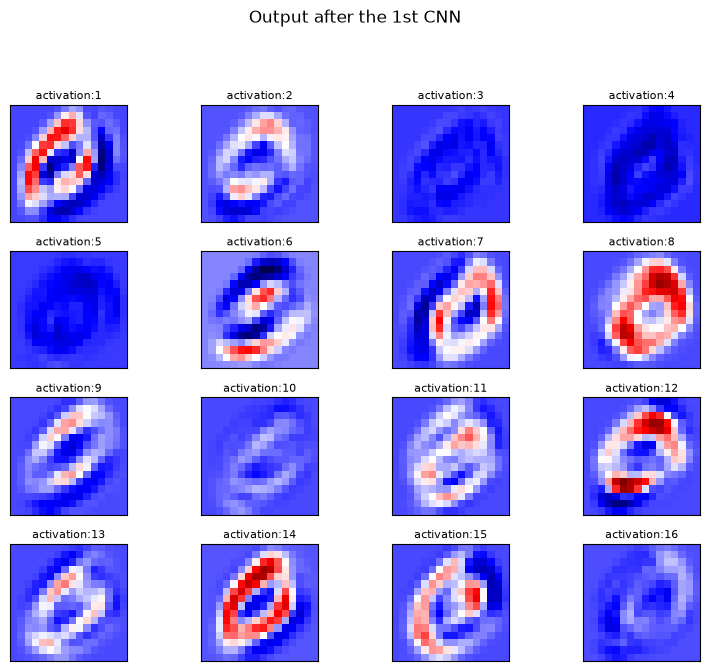

In [37]:
# Plot the outputs after the first CNN

plot_activations(out[0], number_rows=4, name="Output after the 1st CNN")

The following image is the result after applying the relu activation function. 


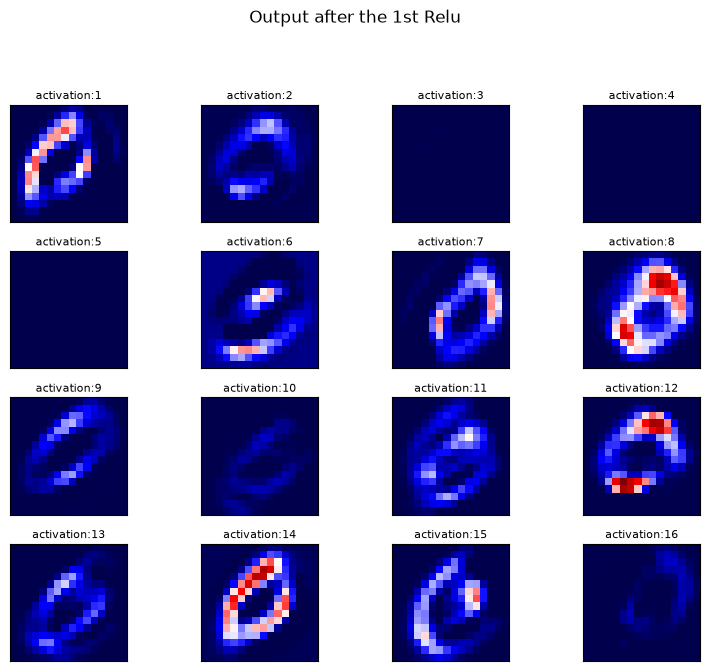

In [38]:
# Plot the outputs after the first Relu

plot_activations(out[1], number_rows=4, name="Output after the 1st Relu")

The following image is the result of the activation map after the second output layer.


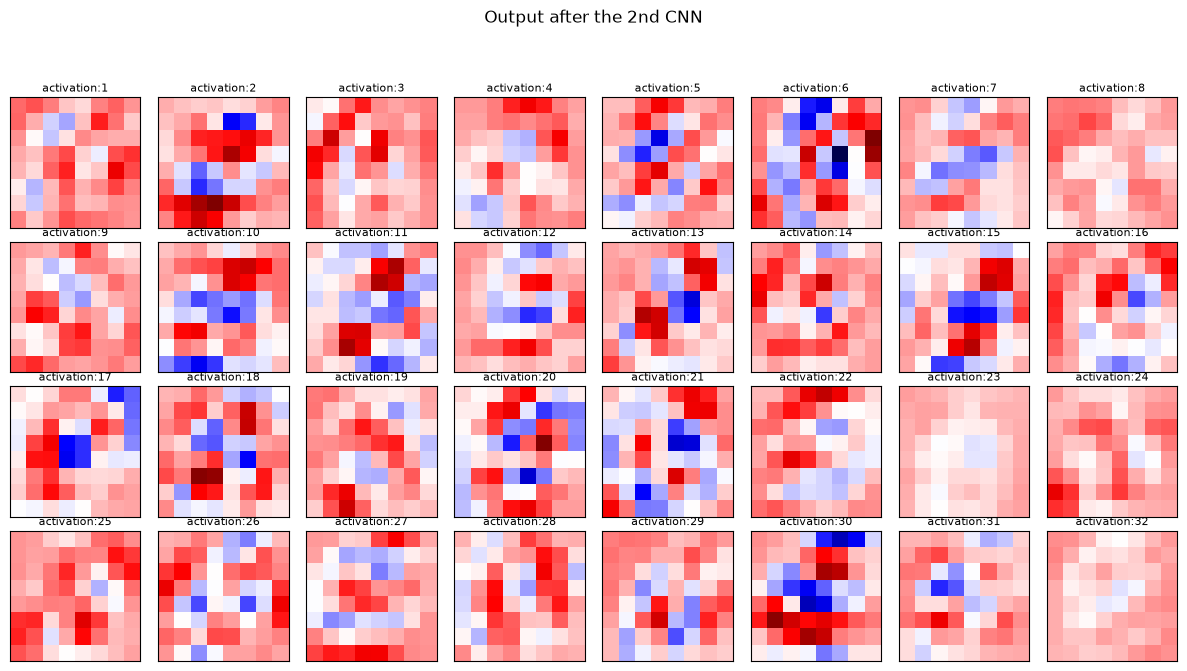

In [39]:
# Plot the outputs after the second CNN

plot_activations(out[2], number_rows=4, name="Output after the 2nd CNN")

The following image is the result of the activation map after applying the second relu. 


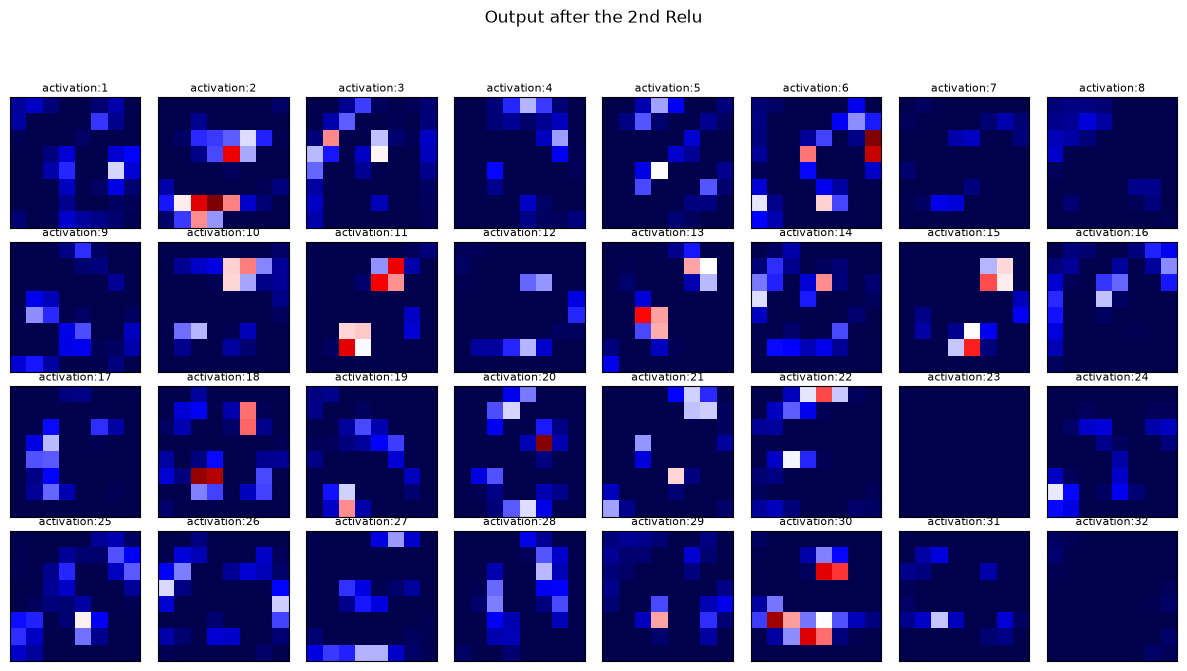

In [40]:
# Plot the outputs after the second Relu

plot_activations(out[3], number_rows=4, name="Output after the 2nd Relu")

You can see the result for the third sample.


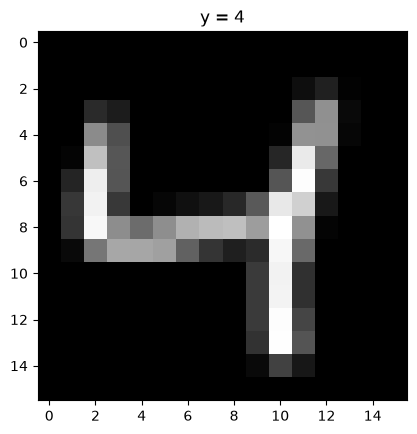

In [41]:
# Show the third image

show_data(train_dataset[2])

In [42]:
# Use the CNN activations class to see the steps

out = model.activations(train_dataset[2][0].view(1, 1, IMAGE_SIZE, IMAGE_SIZE))

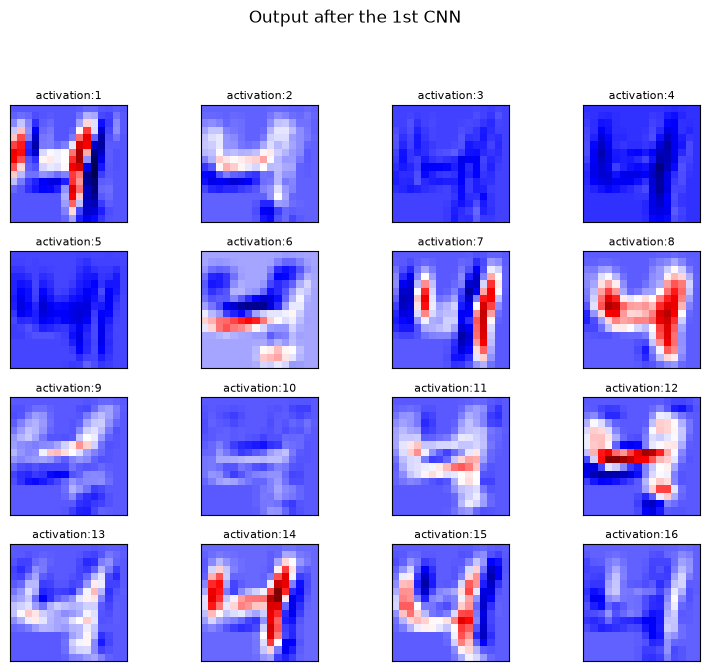

In [43]:
# Plot the outputs after the first CNN

plot_activations(out[0], number_rows=4, name="Output after the 1st CNN")

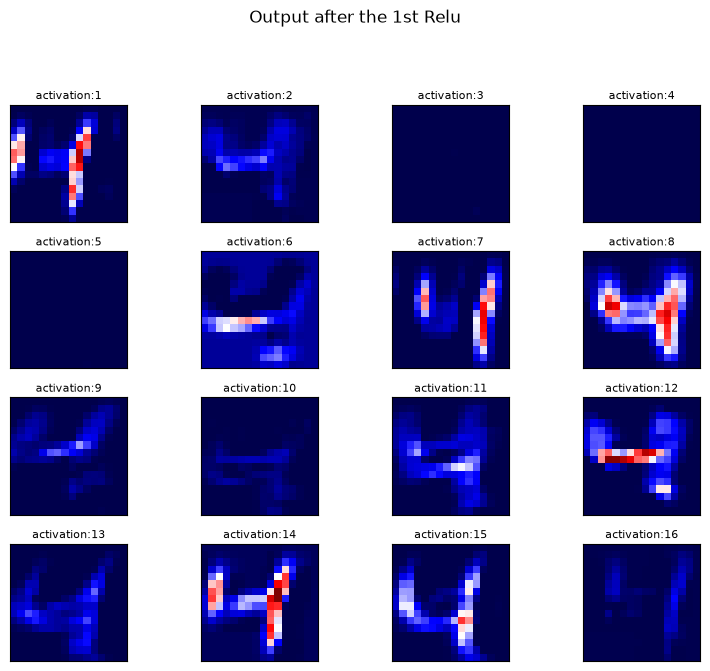

In [44]:
# Plot the outputs after the first Relu

plot_activations(out[1], number_rows=4, name="Output after the 1st Relu")

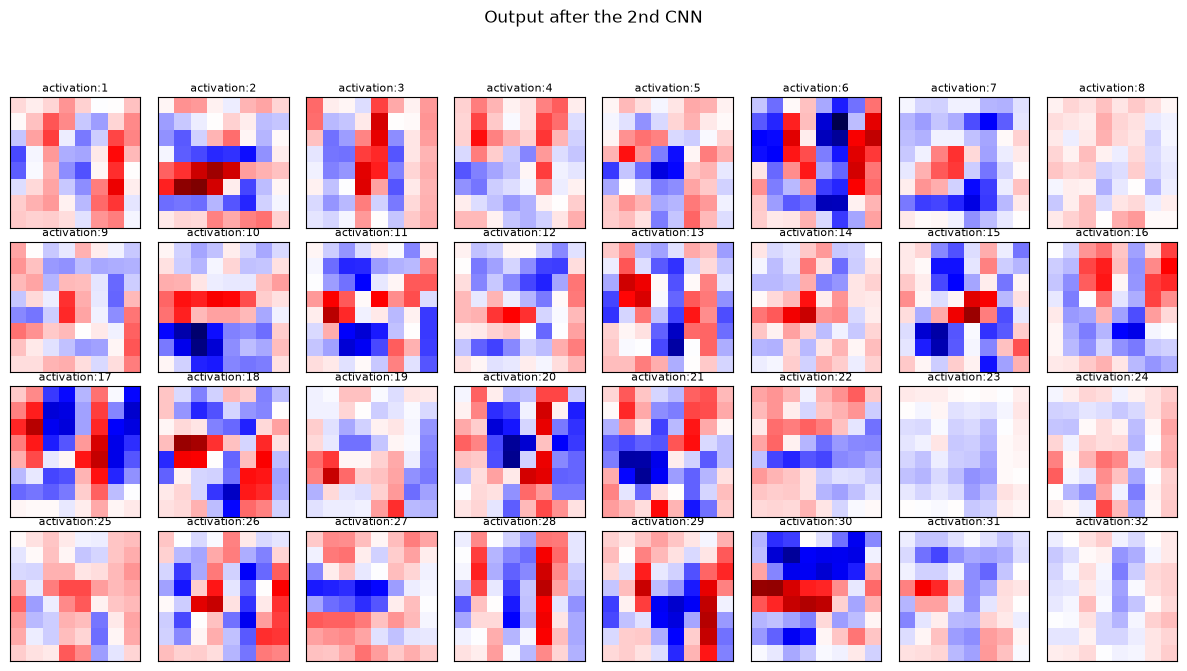

In [45]:
# Plot the outputs after the second CNN

plot_activations(out[2], number_rows=4, name="Output after the 2nd CNN")

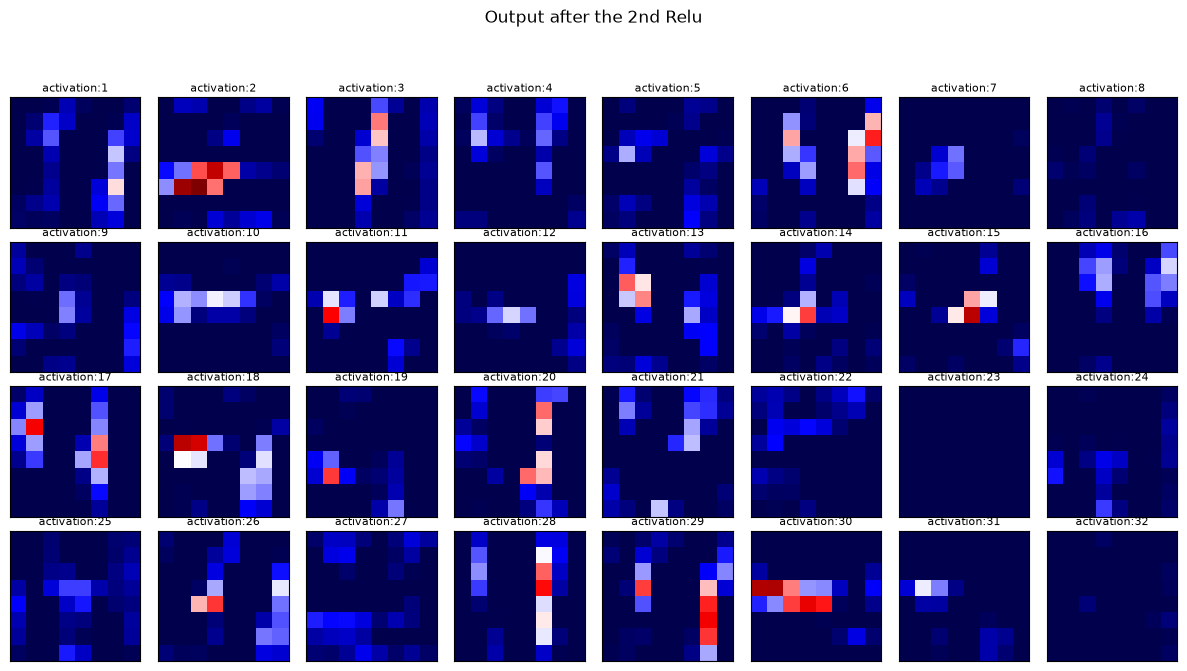

In [46]:
# Plot the outputs after the second Relu

plot_activations(out[3], number_rows=4, name="Output after the 2nd Relu")

Plot the first five misclassified samples:


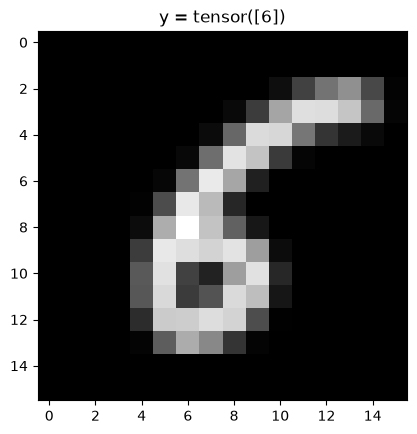

yhat:  tensor([5])

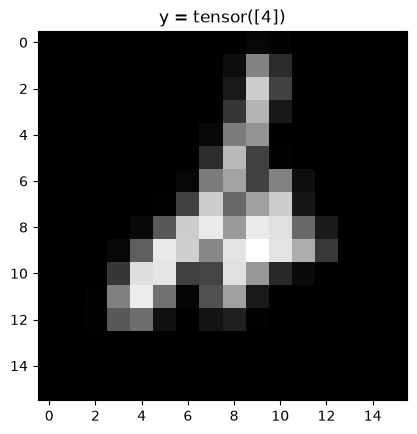

yhat:  tensor([2])

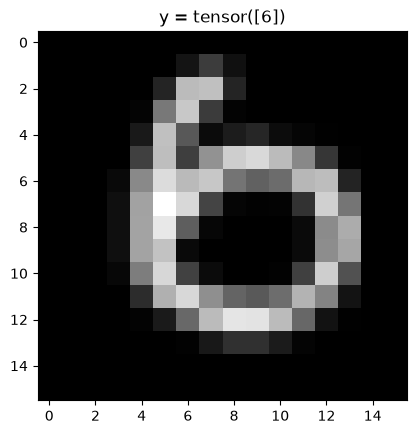

yhat:  tensor([0])

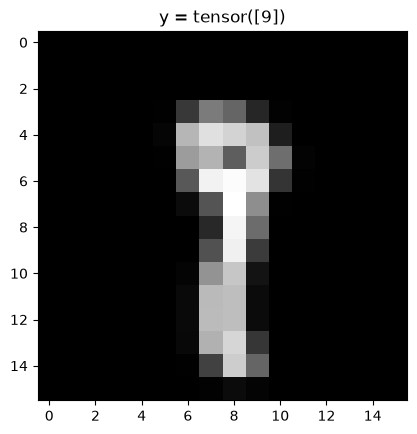

yhat:  tensor([1])

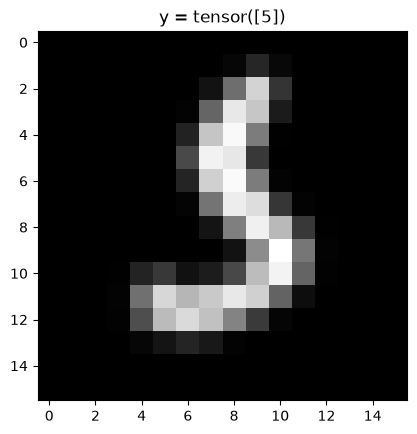

yhat:  tensor([3])

In [47]:
# Plot the misclassified samples

count = 0
for x, y in torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=1):
    z = model(x)
    _, yhat = torch.max(z, 1)
    if yhat != y:
        show_data((x, y))
        plt.show()
        print("yhat: ",yhat)
        count += 1
    if count >= 5:
        break  

<h2>About the Authors:</h2> 

<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


Other contributors: <a href="https://www.linkedin.com/in/michelleccarey/">Michelle Carey</a>, <a href="https://www.linkedin.com/in/jiahui-mavis-zhou-a4537814a/">Mavis Zhou</a>


Thanks to Magnus <a href="http://www.hvass-labs.org/">Erik Hvass Pedersen</a> whose tutorials helped me understand convolutional Neural Network


<!--
## Change Log

| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
|---|---|---|---|
| 2020-09-23 | 2.0 | Srishti | Migrated lab to Markdown and added it to the course repo in GitLab |
| 2026-05-27 | 2.1 |P.Kravitz | Lab headings updated to Markdown and TOC corrected |
-->


## <h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
